# Objectives

- Understand customer purchase behavior using the provided dataset.
- Identify data quality issues (e.g., missing values, duplicates, incorrect data).
- Discover patterns and trends in the data through Exploratory Data Analysis (EDA).
- Analyze customer characteristics to understand who the customers are.
- Identify the best-selling products based on sales.
- Determine which countries generate the most revenue.
- Prepare a complete EDA report to help the company make informed decisions before investing in a recommendation system.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Load the dataset

In [ ]:
# Load the dataset
df = pd.read_excel(r"data/online_retail_II.xlsx")
# Display first five rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Information

In [3]:
# Display the number of rows and columns
print("Shape of Dataset:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

# General information about the dataset
df.info()

Shape of Dataset: (525461, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64   

## Check Missing Values

In [4]:
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


## Check Duplicate Rows

In [5]:
# Count duplicate records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 6865


## Descriptive Statistics

In [6]:
# Display summary statistics for numerical columns
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


## Top 10 Best-Selling Products (Quantity)

In [7]:
# Group data by product description and calculate total quantity sold in descending order
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_quantity)

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64


## Visualization

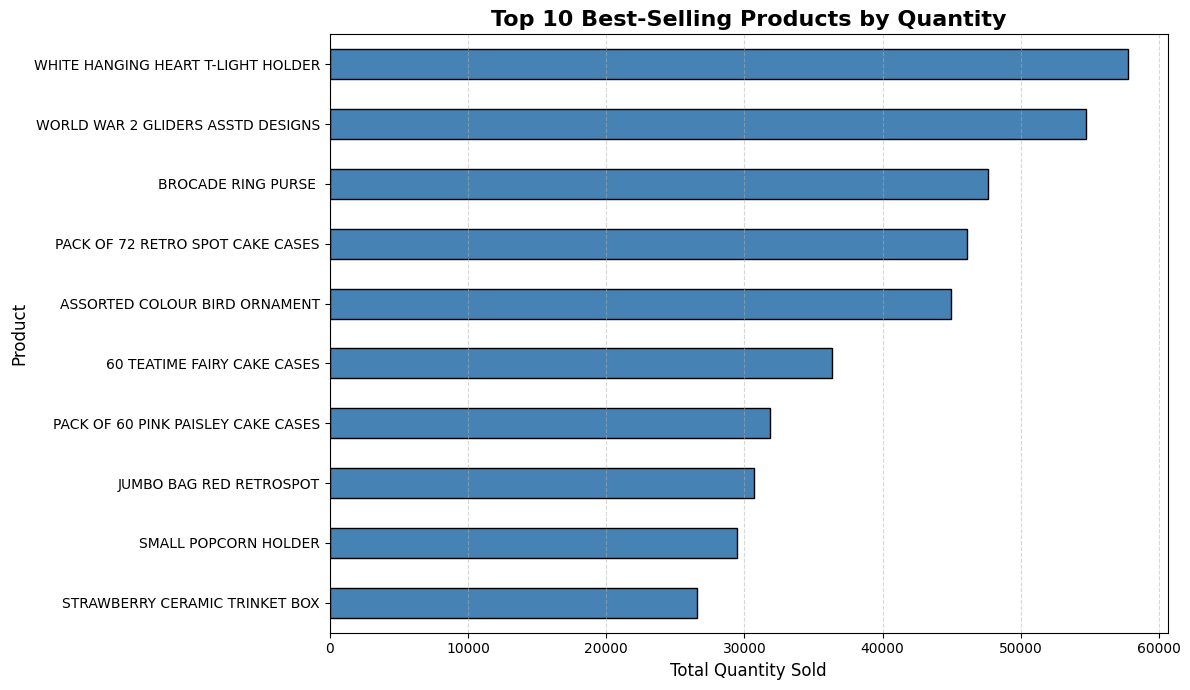

In [8]:
plt.figure(figsize=(12,7))

top_quantity.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title("Top 10 Best-Selling Products by Quantity", fontsize=16, fontweight='bold')
plt.xlabel("Total Quantity Sold", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Top 10 Products by Revenue

In [9]:
# Create a new column for revenue
df["Revenue"] = df["Quantity"] * df["Price"]

# Calculate revenue generated by each product
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_revenue)

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64


## Visualization

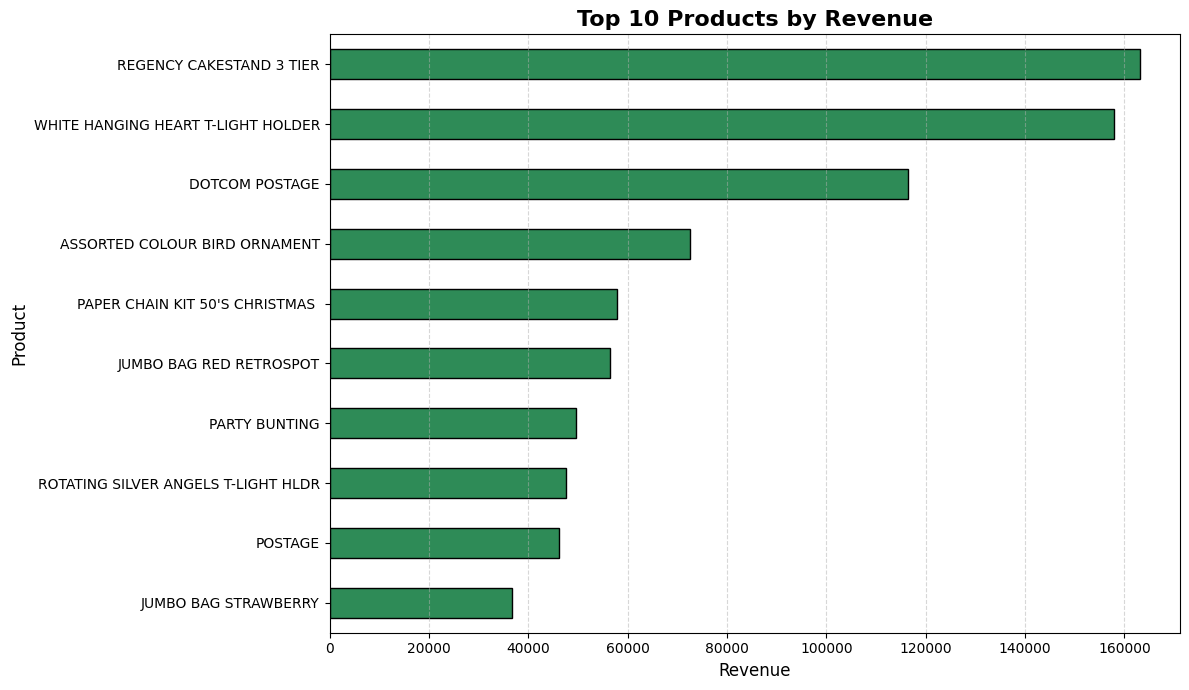

In [10]:
plt.figure(figsize=(12,7))

top_revenue.sort_values().plot(
    kind='barh',
    color='seagreen',
    edgecolor='black'
)

plt.title("Top 10 Products by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Sales Performance by Country

In [11]:
# Calculate total revenue by country
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

## Visualization

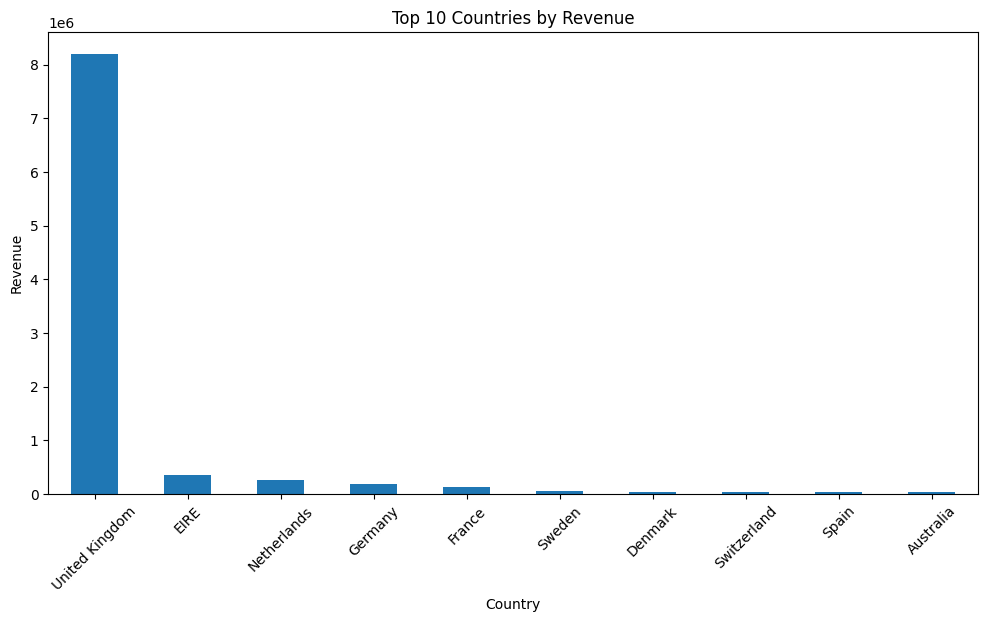

In [12]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Revenue Over Time (Monthly Trend)

In [13]:
# Convert InvoiceDate into datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create a Month column
df["Month"] = df["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue

Month
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12     377488.450
Freq: M, Name: Revenue, dtype: float64

## Visualization

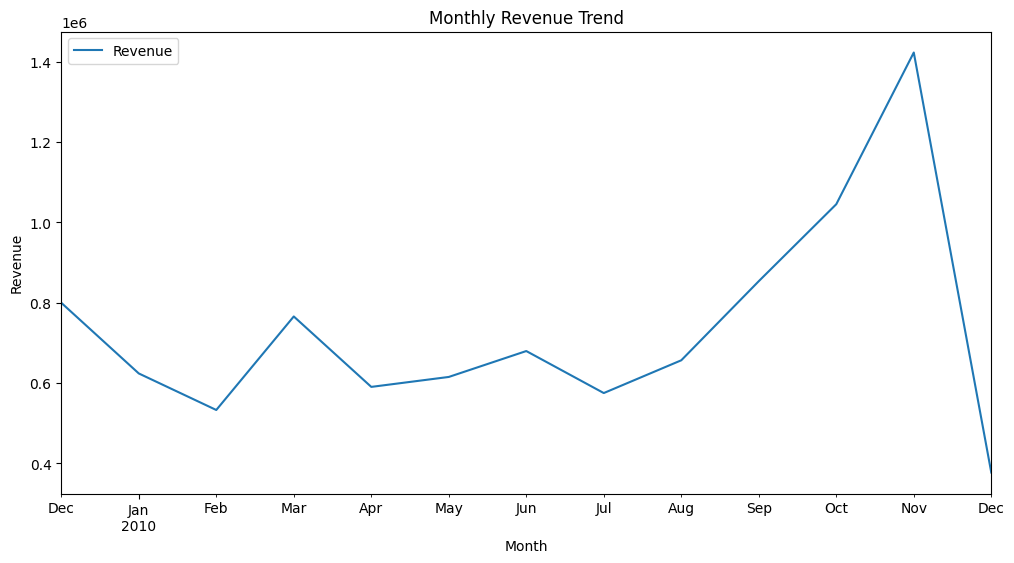

In [14]:
plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend(["Revenue"])

plt.show()

## Correlation Heatmap

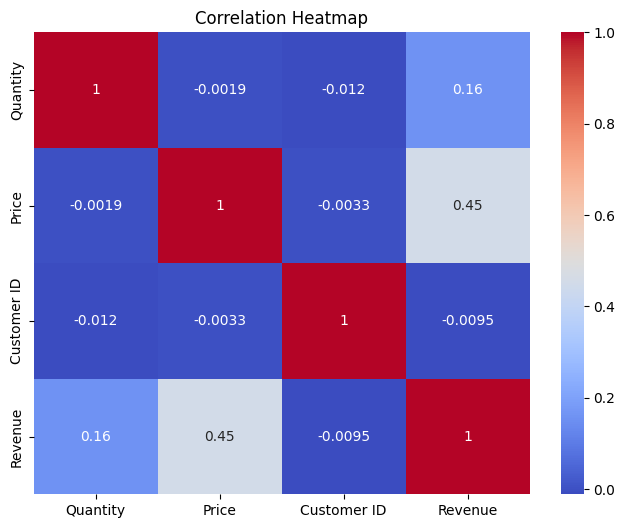

In [15]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix
correlation = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Detect Outliers Using Box Plots

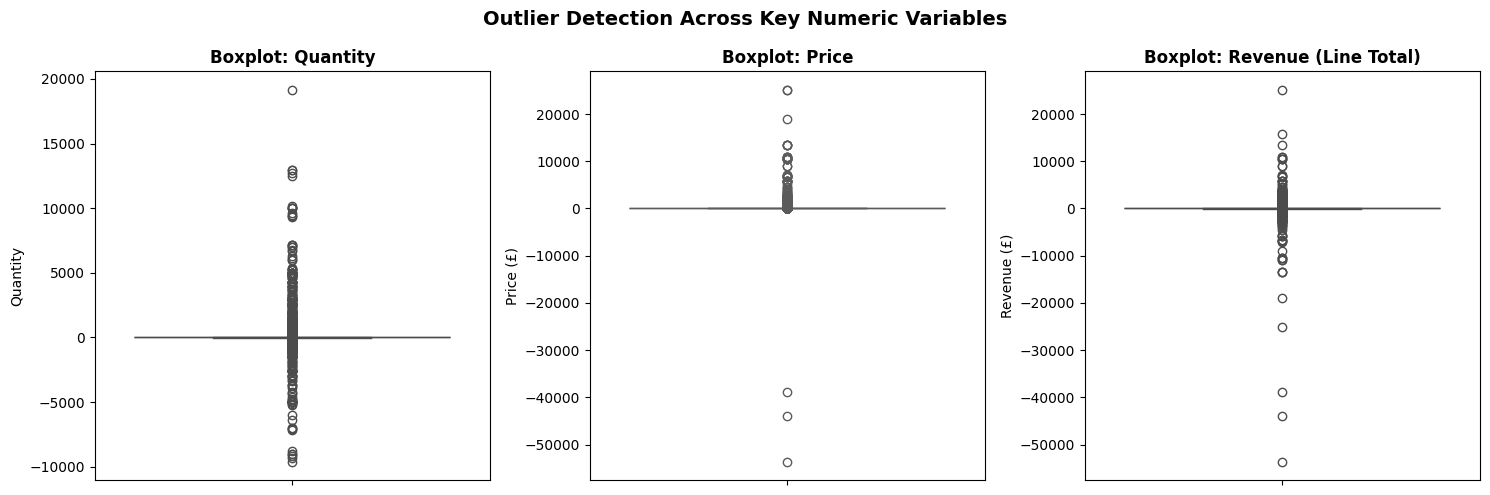

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['Quantity'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Boxplot: Quantity', fontweight='bold')
axes[0].set_ylabel('Quantity')

sns.boxplot(y=df['Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot: Price', fontweight='bold')
axes[1].set_ylabel('Price (£)')

sns.boxplot(y=df['Revenue'], ax=axes[2], color='#55A868')
axes[2].set_title('Boxplot: Revenue (Line Total)', fontweight='bold')
axes[2].set_ylabel('Revenue (£)')

plt.suptitle('Outlier Detection Across Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Outliers value

In [17]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

for col in ['Quantity', 'Price', 'Revenue']:
    n_out = iqr_outlier_count(df[col])
    print(f"{col}: {n_out} outliers ({n_out/len(df)*100:.2f}% of rows) using IQR method")


Quantity: 57870 outliers (11.01% of rows) using IQR method
Price: 35273 outliers (6.71% of rows) using IQR method
Revenue: 45872 outliers (8.73% of rows) using IQR method


## Customer Overview

In [18]:
n_customers = df['Customer ID'].nunique()
n_invoices = df['Invoice'].nunique()
n_countries = df['Country'].nunique()
print(f"Unique customers (excluding missing IDs): {n_customers}")
print(f"Unique invoices: {n_invoices}")
print(f"Countries represented: {n_countries}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")


Unique customers (excluding missing IDs): 4383
Unique invoices: 28816
Countries represented: 40
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


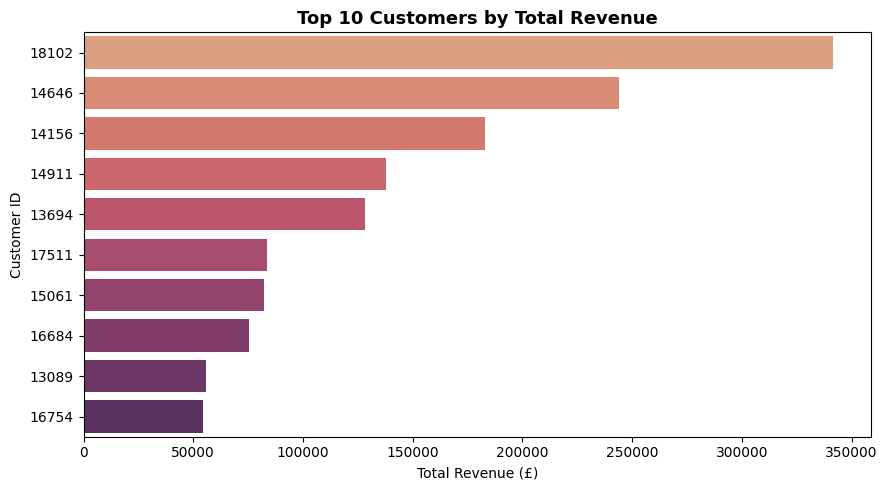

Customer ID
18102.0    341776.73
14646.0    243853.05
14156.0    183180.55
14911.0    137675.91
13694.0    128172.42
17511.0     83760.60
15061.0     82162.74
16684.0     75610.17
13089.0     55828.31
16754.0     54558.18
Name: Revenue, dtype: float64

In [19]:
top_customers = (df[df['Customer ID'].notna()]
                  .groupby('Customer ID')['Revenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(int).astype(str), hue=top_customers.index.astype(int).astype(str), palette='flare', legend=False, ax=ax)
ax.set_title('Top 10 Customers by Total Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Customer ID')
plt.tight_layout()
plt.show()
top_customers


## Business Insights

1. The United Kingdom generates the highest revenue among all countries.
2. A small number of products contribute significantly to total sales.
3. Several missing Customer IDs indicate incomplete customer information.
4. The dataset contains duplicate transactions that should be reviewed before modeling.
5. Revenue increases noticeably during holiday seasons, indicating seasonal demand.